In [ ]:
!pip install -qq pydantic-ai pydantic-graph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.6/94.6 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.8/222.8 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.9/252.9 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.8/210.8 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.3/128.3 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.9/121.9 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.6/271.6 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 65.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.27.0, but you have google-auth 2.38.0 which is incompatible.


In [ ]:
from openai import AsyncAzureOpenAI
from google.colab import userdata

from pprint import pprint
import json
import httpx

import nest_asyncio

from dataclasses import dataclass
from IPython.display import Markdown, display, clear_output, Image
import numpy as np

from typing import Literal, Union, Tuple, List, Dict, Optional, Any

from rich.prompt import Prompt

from pydantic import BaseModel, Field
from pydantic_ai import Agent, Tool, RunContext
from pydantic_ai.models.openai import OpenAIModel
from pydantic_ai.messages import ModelMessage
from pydantic_ai.result import Usage, UsageLimits
from pydantic_graph import BaseNode, End, Graph, GraphRunContext, HistoryStep

async_azure_client = AsyncAzureOpenAI(api_key=userdata.get('AZURE_API_KEY'), azure_endpoint=userdata.get('AZURE_BASE_URL'), api_version=userdata.get('AZURE_API_VERSION'))
nest_asyncio.apply()
model = OpenAIModel('gpt-4o', openai_client=async_azure_client)
from IPython.display import Markdown, display

def printmd(string:str):
    display(Markdown(string))

In [ ]:
inventory_db = {
    "product_a": 100,
    "product_b": 50,
    "product_c": 0,
}

class InventoryResult(BaseModel):
    product: str
    stock: int

agent = Agent(
    model,
    deps_type=str|Tuple,
    result_type=InventoryResult,
    system_prompt="You are an ERP agent that manages inventory."
)
@agent.tool
def check_stock(ctx: RunContext[str]) -> InventoryResult:
    """
    Check the stock level of a product.
    """
    product = ctx.deps
    stock = inventory_db.get(product, 0)
    return InventoryResult(product=product, stock=stock)

@agent.tool
def add_stock(ctx: RunContext[tuple]) -> str:
    """
    Add stock to a product.
    """
    product, amount = ctx.deps
    if product in inventory_db:
        inventory_db[product] += amount
        return f"Added {amount} to {product}. New stock: {inventory_db[product]}"
    else:
        return f"Product {product} does not exist."

# Check stock for product_a
result = agent.run_sync('Check stock for product_a', deps='product_a')
print(result.data)  # Should print the stock level for product_a

# Add stock to product_b
result = agent.run_sync('Add stock to product_b', deps=('product_b', 20))
print(result.data)  # Should confirm the addition of stock

product='product_a' stock=100
product='product_b' stock=70


In [ ]:
# Mock data structures
inventory_db = {
    "service_audit": 10,
    "service_consulting": 5,
    "service_tax": 8,
}

clients_db: Dict[str, List[str]] = {}  # Client name mapped to their projects

# Define the result models
class InventoryResult(BaseModel):
    service: str
    availability: int

class ClientProjectsResult(BaseModel):
    client: str
    projects: List[str]

# Function to check service availability
def check_service_availability(service: str) -> InventoryResult:
    # service = ctx.deps
    availability = inventory_db.get(service, 0)
    return InventoryResult(service=service, availability=availability)

# Function to add a client
def add_client(client_name: str) -> str:
    """
    Add a new client, usually the client name is a real name or company name.
    """
    if client_name not in clients_db:
        clients_db[client_name] = []
        return f"Client {client_name} added successfully."
    else:
        return f"Client {client_name} already exists."

# Function to add a project for a client
def add_project(client_name: str, project_name: str) -> str:
    """
    Add a project for a client, when the client exists.
    """
    if client_name in clients_db:
        clients_db[client_name].append(project_name)
        return f"Project '{project_name}' added for client '{client_name}'."
    else:
        return f"Client {client_name} does not exist."

# Function to get projects for a client
def get_client_projects(client_name:str) -> ClientProjectsResult:
    """
    Get projects for a client.
    """
    projects = clients_db.get(client_name, [])
    return ClientProjectsResult(client=client_name, projects=projects)

# Create the ERP agent
agent = Agent(
    model,
    # deps_type=str|Tuple,
    result_type=InventoryResult,
    system_prompt="You are an ERP agent managing services and clients for a technology company.",
    tools=[
        check_service_availability,
        add_client,
        add_project,
        get_client_projects,
    ]
)

# Run the agent
# Check service availability
result = agent.run_sync('Check availability for service_audit')
print(result.data)  # Should print the availability for service_audit

# Add a new client
result = agent.run_sync('Add client: Acme Corp')
print(result.data)  # Should confirm the addition of the client

# Add a project for the client
result = agent.run_sync('Add project "Q1 Audit" for client Acme Corp')
print(result.data)  # Should confirm the addition of the project

# Get projects for the client
result = agent.run_sync('Get projects for client Acme Corp', deps='Acme Corp')
print(result.data)  # Should list the projects for Acme Corp

service='service_audit' availability=10
service='all' availability=0
service='Q1 Audit' availability=0
service='projects for client Acme Corp' availability=1


In [ ]:
clients_db

{'Acme Corp': ['Q1 Audit']}

In [ ]:
result = agent.run_sync('Add project "Q3 LAT" and "DATA MINING" for client Acme Corp')
print(result.data)

service='Project Management' availability=1


In [ ]:
clients_db

{'Acme Corp': ['Q1 Audit', 'Q3 LAT', 'DATA MINING']}

In [ ]:
pprint(result.all_messages(), width=160)

[ModelRequest(parts=[SystemPromptPart(content='You are an ERP agent managing services and clients for a technology company.',
                                      dynamic_ref=None,
                                      part_kind='system-prompt'),
                     UserPromptPart(content='Add project "Q3 LAT" and "DATA MINING" for client Acme Corp',
                                    timestamp=datetime.datetime(2025, 2, 12, 3, 43, 56, 537150, tzinfo=datetime.timezone.utc),
                                    part_kind='user-prompt')],
              kind='request'),
 ModelResponse(parts=[ToolCallPart(tool_name='add_project',
                                   args='{"client_name": "Acme Corp", "project_name": "Q3 LAT"}',
                                   tool_call_id='call_5K6FOurXgh5sh9hhZiEWauSU',
                                   part_kind='tool-call'),
                      ToolCallPart(tool_name='add_project',
                                   args='{"client_name": "Acme Cor

In [ ]:
# Expanded inventory database with real products
inventory_db: Dict[str, Dict[str, str | int]] = {
    "MacBook Air M2": {"stock": 75, "category": "Laptop", "price": 999, "description": "Apple MacBook Air with M2 chip"},
    "MacBook Pro 14": {"stock": 50, "category": "Laptop", "price": 1999, "description": "Apple MacBook Pro 14-inch with M1 Pro chip"},
    "Surface Laptop 4": {"stock": 30, "category": "Laptop", "price": 999, "description": "Microsoft Surface Laptop 4"},
    "Dell XPS 13": {"stock": 20, "category": "Laptop", "price": 1099, "description": "Dell XPS 13 with Intel Core i7"},
    "HP Spectre x360": {"stock": 15, "category": "Laptop", "price": 1299, "description": "HP Spectre x360 convertible laptop"},
}

# Define the result model for inventory
class InventoryResult(BaseModel):
    product: str
    stock: int
    category: str
    price: int
    description: str


def check_stock(product: str) -> InventoryResult:
    """
    Check the stock level and details of a product.
    """
    product_info = inventory_db.get(product)

    if product_info:
        return InventoryResult(
            product=product,
            stock=product_info["stock"],
            category=product_info["category"],
            price=product_info["price"],
            description=product_info["description"]
        )
    else:
        return InventoryResult(product=product, stock=0, category="", price=0, description="Product does not exist.")

def add_stock(product:str, amount:int) -> str:
    """
    Add stock to a product with its price
    """
    # product, amount = ctx.deps
    if product in inventory_db:
        inventory_db[product]["stock"] += amount
        return f"Added {amount} to {product}. New stock: {inventory_db[product]['stock']}"
    else:
        return f"Product {product} does not exist."

def update_product_info(product: str, category: str, price: int, description: str) -> str:
    """
    Update product information: product, category, price, description
    """
    # product, category, price, description = ctx.deps
    if product in inventory_db:
        inventory_db[product].update({
            "category": category,
            "price": price,
            "description": description
        })
        return f"Updated {product} information successfully."
    else:
        return f"Product {product} does not exist."

# Create the ERP agent
agent = Agent(
    model,
    deps_type=str | Tuple,
    result_type=InventoryResult,
    system_prompt="You are an ERP agent that manages inventory for a technology consulting company.",
    tools=[
        check_stock,
        add_stock,
        update_product_info,
    ]
)

# Check stock for MacBook Air M2
result = agent.run_sync('Check stock for MacBook Air M2',)
print(result.data)  # Should print the stock level and details for MacBook Air M2

# Add stock to Surface Laptop 4
result = agent.run_sync('Add 10 stock to Surface Laptop 4',)
print(result.data)  # Should confirm the addition of stock

# Update Dell XPS 13 information
result = agent.run_sync('Update Dell XPS 13, price 1150 info with latest specs',)
print(result.data)  # Should confirm the update of Dell XPS 13 information

product='MacBook Air M2' stock=75 category='Laptop' price=999 description='Apple MacBook Air with M2 chip'
product='Surface Laptop 4' stock=40 category='Laptop' price=999 description='Microsoft Surface Laptop 4'
product='Dell XPS 13' stock=20 category='Laptop' price=1150 description='The latest Dell XPS 13 with advanced specs, featuring a 10th Gen Intel Core i7 processor, 16GB RAM, 512GB SSD, and a 13.4-inch FHD+ display.'


In [ ]:
inventory_db

{'MacBook Air M2': {'stock': 75,
  'category': 'Laptop',
  'price': 999,
  'description': 'Apple MacBook Air with M2 chip'},
 'MacBook Pro 14': {'stock': 50,
  'category': 'Laptop',
  'price': 1999,
  'description': 'Apple MacBook Pro 14-inch with M1 Pro chip'},
 'Surface Laptop 4': {'stock': 40,
  'category': 'Laptop',
  'price': 999,
  'description': 'Microsoft Surface Laptop 4'},
 'Dell XPS 13': {'stock': 20,
  'category': 'Laptop',
  'price': 1150,
  'description': 'The latest Dell XPS 13 with advanced specs, featuring a 10th Gen Intel Core i7 processor, 16GB RAM, 512GB SSD, and a 13.4-inch FHD+ display.'},
 'HP Spectre x360': {'stock': 15,
  'category': 'Laptop',
  'price': 1299,
  'description': 'HP Spectre x360 convertible laptop'}}

In [ ]:
result = agent.run_sync(f'Check the stock of all {list(inventory_db.keys())}',result_type=str)
print(result.data)

The stock levels and details for the requested products are:

1. **MacBook Air M2**
   - Stock: 75
   - Category: Laptop
   - Price: $999
   - Description: Apple MacBook Air with M2 chip

2. **MacBook Pro 14**
   - Stock: 50
   - Category: Laptop
   - Price: $1999
   - Description: Apple MacBook Pro 14-inch with M1 Pro chip

3. **Surface Laptop 4**
   - Stock: 40
   - Category: Laptop
   - Price: $999
   - Description: Microsoft Surface Laptop 4

4. **Dell XPS 13**
   - Stock: 20
   - Category: Laptop
   - Price: $1150
   - Description: The latest Dell XPS 13 with advanced specs, featuring a 10th Gen Intel Core i7 processor, 16GB RAM, 512GB SSD, and a 13.4-inch FHD+ display.

5. **HP Spectre x360**
   - Stock: 15
   - Category: Laptop
   - Price: $1299
   - Description: HP Spectre x360 convertible laptop


In [ ]:
result = agent.run_sync(f'Check the stock of only apple products {list(inventory_db.keys())}',result_type=str)
print(result.data)

Here are the current stock levels for the Apple products:

1. **MacBook Air M2**
   - Stock: 75 units
   - Category: Laptop
   - Price: $999
   - Description: Apple MacBook Air with M2 chip

2. **MacBook Pro 14**
   - Stock: 50 units
   - Category: Laptop
   - Price: $1999
   - Description: Apple MacBook Pro 14-inch with M1 Pro chip


# Some Ideas(Mocks)

## Inventory Management Agent

In [ ]:
# Mock Data Structure
inventory_db: Dict[str, Dict[str, str | int]] = {
    "Smartphone X": {"stock": 100, "category": "Electronics", "price": 799, "description": "Latest Smartphone X with advanced features"},
    "Wireless Headphones": {"stock": 50, "category": "Accessories", "price": 199, "description": "Noise-cancelling wireless headphones"},
    "Gaming Laptop": {"stock": 30, "category": "Laptop", "price": 1499, "description": "High-performance gaming laptop"},
}

# Result Model
class InventoryResult(BaseModel):
    product: str
    stock: int
    category: str
    price: int
    description: str

# Functions
def check_stock(product: str) -> InventoryResult:
    product_info = inventory_db.get(product)
    if product_info:
        return InventoryResult(
            product=product,
            stock=product_info["stock"],
            category=product_info["category"],
            price=product_info["price"],
            description=product_info["description"]
        )
    else:
        return InventoryResult(product=product, stock=0, category="", price=0, description="Product does not exist.")

def add_stock(product: str, amount: int) -> str:
    if product in inventory_db:
        inventory_db[product]["stock"] += amount
        return f"Added {amount} to {product}. New stock: {inventory_db[product]['stock']}"
    else:
        return f"Product {product} does not exist."

def update_product_info(product: str, category: str, price: int, description: str) -> str:
    if product in inventory_db:
        inventory_db[product].update({
            "category": category,
            "price": price,
            "description": description
        })
        return f"Updated {product} information successfully."
    else:
        return f"Product {product} does not exist."

# Create the Agent
inventory_agent = Agent(
    model,
    deps_type=str | Tuple,
    result_type=InventoryResult,
    system_prompt="You are an inventory management agent for a retail company.",
    tools=[
        check_stock,
        add_stock,
        update_product_info,
    ]
)

# Example Usage
result = inventory_agent.run_sync('Check stock for Smartphone X')
print(result.data)

result = inventory_agent.run_sync('Add 20 stock to Wireless Headphones')
print(result.data)

result = inventory_agent.run_sync('Update Gaming Laptop, price 1399 with latest specs')
print(result.data)

product='Smartphone X' stock=100 category='Electronics' price=799 description='Latest Smartphone X with advanced features'
product='Wireless Headphones' stock=70 category='Accessories' price=199 description='Noise-cancelling wireless headphones'
product='Gaming Laptop' stock=30 category='Electronics' price=1399 description='Latest specs'


## Finance Management Agent

In [ ]:
# Mock Data Structure
finance_db: Dict[str, float] = {
    "total_revenue": 500000.0,
    "total_expenses": 300000.0,
    "net_profit": 200000.0,
}

# Result Model
class FinanceResult(BaseModel):
    revenue: float
    expenses: float
    net_profit: float

# Functions
def check_financials() -> FinanceResult:
    return FinanceResult(
        revenue=finance_db["total_revenue"],
        expenses=finance_db["total_expenses"],
        net_profit=finance_db["net_profit"]
    )

def record_expense(amount: float, description: str) -> str:
    finance_db["total_expenses"] += amount
    finance_db["net_profit"] = finance_db["total_revenue"] - finance_db["total_expenses"]
    return f"Recorded expense of {amount} for {description}."

def record_revenue(amount: float, description: str) -> str:
    finance_db["total_revenue"] += amount
    finance_db["net_profit"] = finance_db["total_revenue"] - finance_db["total_expenses"]
    return f"Recorded revenue of {amount} for {description}."

# Create the Agent
finance_agent = Agent(
    model,
    deps_type=str | Tuple,
    result_type=FinanceResult,
    system_prompt="You are a finance management agent for a corporate entity.",
    tools=[
        check_financials,
        record_expense,
        record_revenue,
    ]
)

# Example Usage
result = finance_agent.run_sync('Check financials')
print(result.data)

result = finance_agent.run_sync('Record expense of 500 for office supplies')
print(result.data)

result = finance_agent.run_sync('Record revenue of 10000 for project completion')
print(result.data)

revenue=500000.0 expenses=300000.0 net_profit=200000.0
revenue=500000.0 expenses=300500.0 net_profit=199500.0
revenue=510000.0 expenses=300500.0 net_profit=209500.0


## Sales Management Agent

In [ ]:
# Mock Data Structure
sales_db: Dict[str, Dict[str, int]] = {
    "total_sales": 1500,
    "sales_by_product": {
        "Smartphone X": 300,
        "Wireless Headphones": 200,
        "Gaming Laptop": 100,
    },
}

# Result Model
class SalesResult(BaseModel):
    total_sales: int
    sales_by_product: Dict[str, int]

# Functions
def check_sales() -> SalesResult:
    return SalesResult(
        total_sales=sales_db["total_sales"],
        sales_by_product=sales_db["sales_by_product"]
    )

def record_sale(product: str, quantity: int) -> str:
    if product in sales_db["sales_by_product"]:
        sales_db["sales_by_product"][product] += quantity
        sales_db["total_sales"] += quantity
        return f"Recorded sale of {quantity} units of {product}."
    else:
        return f"Product {product} does not exist in sales records."

# Create the Agent
sales_agent = Agent(
    model,
    deps_type=str | Tuple,
    result_type=SalesResult,
    system_prompt="You are a sales management agent for a retail company.",
    tools=[
        check_sales,
        record_sale,
    ]
)

# Example Usage
result = sales_agent.run_sync('Check sales')
print(result.data)

result = sales_agent.run_sync('Record sale of 5 units of Smartphone X')
print(result.data)

total_sales=1500 sales_by_product={'Smartphone X': 300, 'Wireless Headphones': 200, 'Gaming Laptop': 100}
total_sales=1505 sales_by_product={'Smartphone X': 305, 'Wireless Headphones': 200, 'Gaming Laptop': 100}


## CRM Agent

In [ ]:
# Mock Data Structure
clients_db: Dict[str, Dict[str, List[str]]] = {
    "Acme Corp": {"contact": "John Doe", "projects": ["Project A", "Project B"]},
    "Beta LLC": {"contact": "Jane Smith", "projects": []},
}

# Result Model
class ClientResult(BaseModel):
    client: str
    contact: str
    projects: List[str]

# Functions
def get_client_info(client_name: str) -> ClientResult:
    client_info = clients_db.get(client_name)
    if client_info:
        return ClientResult(
            client=client_name,
            contact=client_info["contact"],
            projects=client_info["projects"]
        )
    else:
        return ClientResult(client=client_name, contact="", projects=[])

def add_client(client_name: str, contact: str) -> str:
    if client_name not in clients_db:
        clients_db[client_name] = {"contact": contact, "projects": []}
        return f"Client {client_name} added successfully."
    else:
        return f"Client {client_name} already exists."

# Create the Agent
crm_agent = Agent(
    model,
    deps_type=str|Tuple,
    result_type=ClientResult,
    system_prompt="You are a CRM agent managing client relationships.",
    tools=[
        get_client_info,
        add_client,
    ]
)

# Example Usage
result = crm_agent.run_sync('Get client info for Acme Corp')
print(result.data)

result = crm_agent.run_sync('Add client Beta LLC with contact Jane Smith')
print(result.data)

client='Acme Corp' contact='John Doe' projects=['Project A', 'Project B']
client='Beta LLC' contact='Jane Smith' projects=[]


## Purchasing Management Agent

In [ ]:
# Mock Data Structure
purchases_db: Dict[str, Dict[str, float]] = {
    "total_purchases": 200000.0,
    "pending_orders": 5,
}

# Result Model
class PurchaseResult(BaseModel):
    total_purchases: float
    pending_orders: int

# Functions
def check_purchases() -> PurchaseResult:
    return PurchaseResult(
        total_purchases=purchases_db["total_purchases"],
        pending_orders=purchases_db["pending_orders"]
    )

def place_order(supplier: str, amount: float) -> str:
    purchases_db["total_purchases"] += amount
    purchases_db["pending_orders"] += 1
    return f"Placed order with {supplier} for {amount}."

# Create the Agent
purchasing_agent = Agent(
    model,
    deps_type=str|Tuple,
    result_type=PurchaseResult,
    system_prompt="You are a purchasing management agent for a retail company.",
    tools=[
        check_purchases,
        place_order,
    ]
)

# Example Usage
result = purchasing_agent.run_sync('Check purchases')
print(result.data)

result = purchasing_agent.run_sync('Place order with Supplier A for 15000')
print(result.data)

total_purchases=200000.0 pending_orders=5
total_purchases=215000.0 pending_orders=6


## Customer Service Agent

In [ ]:
# Mock Data Structure
customer_queries_db: Dict[str, List[str]] = {
    "open_queries": ["Order #1234 delayed", "Product return request"],
    "resolved_queries": [],
}

# Result Model
class CustomerServiceResult(BaseModel):
    open_queries: List[str]
    resolved_queries: List[str]

# Functions
def check_customer_queries() -> CustomerServiceResult:
    """
    Check all customer queries.
    """
    return CustomerServiceResult(
        open_queries=customer_queries_db["open_queries"],
        resolved_queries=customer_queries_db["resolved_queries"]
    )

def resolve_query(query: str) -> str:
    """
    Resolve a given query
    """
    print('resoving...',query)
    if query in customer_queries_db["open_queries"]:
        customer_queries_db["open_queries"].remove(query)
        customer_queries_db["resolved_queries"].append(query)
        return f"Resolved query: {query}."
    else:
        return f"Query: {query} not found in open queries."

# Create the Agent
customer_service_agent = Agent(
    model,
    deps_type=str|Tuple,
    result_type=CustomerServiceResult,
    system_prompt=(
        "You are a customer service agent handling customer inquiries.",
        "When the user request checking, just check, not resolve anything.", # do not comment
        "Only resolve inqueries tells by the user"
        ),
    tools=[
        check_customer_queries,
        resolve_query,
    ]
)

# Example Usage
result = customer_service_agent.run_sync('Check customer queries')
print(result.data)

result = customer_service_agent.run_sync('Resolve query: Order #1234 delayed')
print(result.data)

result = customer_service_agent.run_sync('Check customer queries')
print(result.data)

open_queries=['Order #1234 delayed', 'Product return request'] resolved_queries=[]
resoving... Order #1234 delayed
open_queries=['Product return request'] resolved_queries=['Order #1234 delayed']
open_queries=['Product return request'] resolved_queries=['Order #1234 delayed']


## HR Management Agent

In [ ]:
# Mock Data Structure
employees_db: Dict[str, Dict[str, str | int]] = {
    "John Doe": {"position": "Software Engineer", "salary": 80000, "status": "Active"},
    "Jane Smith": {"position": "Project Manager", "salary": 90000, "status": "Active"},
}

# Result Model
class HRResult(BaseModel):
    employee: str
    position: str
    salary: int
    status: str

# Functions
def get_employee_info(employee_name: str) -> HRResult:
    employee_info = employees_db.get(employee_name)
    if employee_info:
        return HRResult(
            employee=employee_name,
            position=employee_info["position"],
            salary=employee_info["salary"],
            status=employee_info["status"]
        )
    else:
        return HRResult(employee=employee_name, position="", salary=0, status="Not Found")

def add_employee(employee_name: str, position: str, salary: int) -> str:
    if employee_name not in employees_db:
        employees_db[employee_name] = {"position": position, "salary": salary, "status": "Active"}
        return f"Employee {employee_name} added successfully."
    else:
        return f"Employee {employee_name} already exists."

# Create the Agent
hr_agent = Agent(
    model,
    deps_type=str|Tuple,
    result_type=HRResult,
    system_prompt="You are an HR management agent for a corporate entity.",
    tools=[
        get_employee_info,
        add_employee,
    ]
)

# Example Usage
result = hr_agent.run_sync('Get employee info for John Doe')
print(result.data)

result = hr_agent.run_sync('Add employee Alice Johnson as HR Manager with salary 75000')
print(result.data)

employee='John Doe' position='Software Engineer' salary=80000 status='Active'
employee='Alice Johnson' position='HR Manager' salary=75000 status='Active'


In [ ]:
employees_db

{'John Doe': {'position': 'Software Engineer',
  'salary': 80000,
  'status': 'Active'},
 'Jane Smith': {'position': 'Project Manager',
  'salary': 90000,
  'status': 'Active'},
 'Alice Johnson': {'position': 'HR Manager',
  'salary': 75000,
  'status': 'Active'}}

## Manufacturing Agent

In [ ]:
# Mock Data Structure
production_db: Dict[str, Dict[str, int]] = {
    "total_units_produced": 10000,
    "defective_units": 200,
}

# Result Model
class ManufacturingResult(BaseModel):
    total_units_produced: int
    defective_units: int

# Functions
def check_production_stats() -> ManufacturingResult:
    return ManufacturingResult(
        total_units_produced=production_db["total_units_produced"],
        defective_units=production_db["defective_units"]
    )

def record_production(units: int) -> str:
    production_db["total_units_produced"] += units
    return f"Recorded production of {units} units."

# Create the Agent
manufacturing_agent = Agent(
    model,
    deps_type=str | Tuple,
    result_type=ManufacturingResult,
    system_prompt="You are a manufacturing agent overseeing production processes.",
    tools=[
        check_production_stats,
        record_production,
    ]
)

# Example Usage
result = manufacturing_agent.run_sync('Check production stats')
print(result.data)

result = manufacturing_agent.run_sync('Record production of 500 units')
print(result.data)

total_units_produced=10000 defective_units=200
total_units_produced=10500 defective_units=200


# PydanticGraph

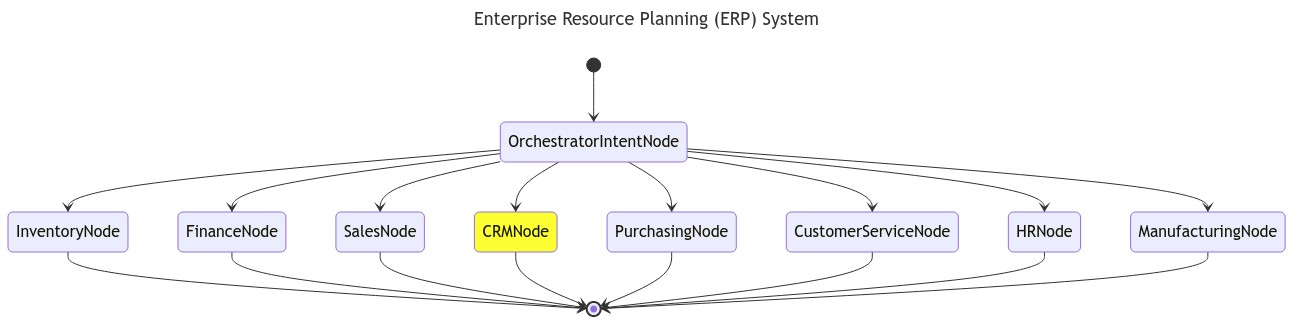

In [ ]:
@dataclass
class OrchestratorIntentState:
   agent_used: str | None = None
   result_type: str | None = None

@dataclass
class GraphDependencies:
    api_key: str | None = None
    http_client: str | None = None
    dbEngine: str | None = None
    searchEngine: str | None = None

@dataclass
class BaseNodeWithRun(BaseNode[OrchestratorIntentState, GraphDependencies, End]):
    input: str

    async def run(self, ctx: GraphRunContext[OrchestratorIntentState, GraphDependencies]) -> End:
        assert hasattr(self, "agent") and self.agent is not None, "Agent is not defined, please define a variable `agent` in the subclass of BaseNodeWithRun"
        # print('--> state', ctx.state)
        # print('--> deps', ctx.deps)
        result = await self.agent.run(self.input, result_type=ctx.state.result_type)
        return End(data=result.data)

class InventoryNode(BaseNodeWithRun):
    agent = inventory_agent
    # pass

class FinanceNode(BaseNodeWithRun):
    agent = finance_agent

class SalesNode(BaseNodeWithRun):
    agent = sales_agent

class CRMNode(BaseNodeWithRun):
    agent = crm_agent

class PurchasingNode(BaseNodeWithRun):
    agent = purchasing_agent

class CustomerServiceNode(BaseNodeWithRun):
    agent = customer_service_agent

class HRNode(BaseNodeWithRun):
    agent = hr_agent

class ManufacturingNode(BaseNodeWithRun):
    agent = manufacturing_agent


agent_mapping = {
        'inventory_agent': InventoryNode,
        'finance_agent': FinanceNode,
        'sales_agent': SalesNode,
        'CRM_agent': CRMNode,
        'purchasing_agent': PurchasingNode,
        'customer_service_agent': CustomerServiceNode,
        'HR_agent': HRNode,
        'manufacturing_agent': ManufacturingNode,
    }


@dataclass
class OrchestratorIntentNode(BaseNode[OrchestratorIntentState, GraphDependencies, InventoryNode|FinanceNode|SalesNode|CRMNode|PurchasingNode|CustomerServiceNode|HRNode|ManufacturingNode]):
    input: str
    class OrchestratorResponse(BaseModel):
        user_inquery: str = Field(description="The user's inquery ") # or transform into a formal question
        next_node: str = Field(description=(
            f"One of the following strings: {list(agent_mapping.keys())}"
            ))
    __orchestrator_agent = Agent(model, result_type=OrchestratorResponse,
                                 system_prompt="Your goal is to determinate which agent the user needs to achieve their request")

    async def run(self, ctx: GraphRunContext[OrchestratorIntentState, GraphDependencies]) -> InventoryNode|FinanceNode|SalesNode|CRMNode|PurchasingNode|CustomerServiceNode|HRNode|ManufacturingNode:
        result = await self.__orchestrator_agent.run(self.input)
        ctx.state.agent_used = result.data.next_node
        next_node = agent_mapping.get(result.data.next_node, CRMNode) # CRM node is selected by default
        return next_node(input=result.data.user_inquery)


async def ask_to_ERP_AI_system(user_input: str):
    state = OrchestratorIntentState()
    deps = GraphDependencies(api_key='sk-', http_client='bear xxx', )
    node = OrchestratorIntentNode(input=user_input)
    history: list[HistoryStep[OrchestratorIntentState]] = []
    while True:
        print('History', history)
        if isinstance(node, BaseNode):
            print(f'Running {type(node)} ...')
        elif isinstance(node, End):
            print(f'{node.data}')
            print('-'*50, "Snapshots",'-'*50)
            pprint([e.data_snapshot() for e in history])
            break
        node = await ERP_graph.next(node, history,
                                    state=state,
                                    deps=deps
                                    )


ERP_graph = Graph(nodes=(
    OrchestratorIntentNode, InventoryNode, FinanceNode, SalesNode, CRMNode, PurchasingNode, CustomerServiceNode, HRNode, ManufacturingNode
    ), name="Enterprise Resource Planning (ERP) System")
display(Image(ERP_graph.mermaid_image(start_node=OrchestratorIntentNode, highlighted_nodes=[CRMNode])))

In [ ]:
node = OrchestratorIntentNode(input='Check stock for Smartphone X')
result, history = await ERP_graph.run(node, state=OrchestratorIntentState())
print('history -->', history)
print(result)
print('-'*50)
result, history = await ERP_graph.run(node, state=OrchestratorIntentState(result_type=str))
print('history -->', history)
print(result)

history --> [NodeStep(state=OrchestratorIntentState(agent_used='inventory_agent', result_type=None), node=OrchestratorIntentNode(input='Check stock for Smartphone X'), start_ts=datetime.datetime(2025, 2, 12, 4, 48, 45, 583575, tzinfo=datetime.timezone.utc), duration=0.9364630689997284, kind='node'), NodeStep(state=OrchestratorIntentState(agent_used='inventory_agent', result_type=None), node=InventoryNode(input='Check stock for Smartphone X'), start_ts=datetime.datetime(2025, 2, 12, 4, 48, 46, 520103, tzinfo=datetime.timezone.utc), duration=1.257345389999955, kind='node'), EndStep(result=End(data=InventoryResult(product='Smartphone X', stock=100, category='Electronics', price=799, description='Latest Smartphone X with advanced features')), ts=datetime.datetime(2025, 2, 12, 4, 48, 47, 777474, tzinfo=datetime.timezone.utc), kind='end')]
product='Smartphone X' stock=100 category='Electronics' price=799 description='Latest Smartphone X with advanced features'
-------------------------------

# Testing ERP SYSTEM

In [ ]:
await ask_to_ERP_AI_system('Check stock for Smartphone X')

History []
Running <class '__main__.OrchestratorIntentNode'> ...
History [NodeStep(state=OrchestratorIntentState(agent_used='inventory_agent', result_type=None), node=OrchestratorIntentNode(input='Check stock for Smartphone X'), start_ts=datetime.datetime(2025, 2, 12, 4, 45, 16, 681912, tzinfo=datetime.timezone.utc), duration=0.5725954849999653, kind='node')]
Running <class '__main__.InventoryNode'> ...
History [NodeStep(state=OrchestratorIntentState(agent_used='inventory_agent', result_type=None), node=OrchestratorIntentNode(input='Check stock for Smartphone X'), start_ts=datetime.datetime(2025, 2, 12, 4, 45, 16, 681912, tzinfo=datetime.timezone.utc), duration=0.5725954849999653, kind='node'), NodeStep(state=OrchestratorIntentState(agent_used='inventory_agent', result_type=None), node=InventoryNode(input='Check stock for Smartphone X'), start_ts=datetime.datetime(2025, 2, 12, 4, 45, 17, 255251, tzinfo=datetime.timezone.utc), duration=0.9913984299996628, kind='node')]
product='Smartpho

In [ ]:
await ask_to_ERP_AI_system('Record expense of 500 for office supplies')

History []
Running <class '__main__.OrchestratorIntentNode'> ...
History [NodeStep(state=OrchestratorIntentState(agent_used='finance_agent', result_type=None), node=OrchestratorIntentNode(input='Record expense of 500 for office supplies'), start_ts=datetime.datetime(2025, 2, 12, 4, 45, 25, 777540, tzinfo=datetime.timezone.utc), duration=2.506324417999622, kind='node')]
Running <class '__main__.FinanceNode'> ...
History [NodeStep(state=OrchestratorIntentState(agent_used='finance_agent', result_type=None), node=OrchestratorIntentNode(input='Record expense of 500 for office supplies'), start_ts=datetime.datetime(2025, 2, 12, 4, 45, 25, 777540, tzinfo=datetime.timezone.utc), duration=2.506324417999622, kind='node'), NodeStep(state=OrchestratorIntentState(agent_used='finance_agent', result_type=None), node=FinanceNode(input='Record expense of 500 for office supplies'), start_ts=datetime.datetime(2025, 2, 12, 4, 45, 28, 284169, tzinfo=datetime.timezone.utc), duration=1.427716688000146, kind=

In [ ]:
await ask_to_ERP_AI_system('Record sale of 5 units of Smartphone X')

History []
Running <class '__main__.OrchestratorIntentNode'> ...
History [NodeStep(state=OrchestratorIntentState(agent_used='sales_agent', result_type=None), node=OrchestratorIntentNode(input='Record sale of 5 units of Smartphone X'), start_ts=datetime.datetime(2025, 2, 12, 4, 45, 29, 724363, tzinfo=datetime.timezone.utc), duration=0.9878154400003041, kind='node')]
Running <class '__main__.SalesNode'> ...
History [NodeStep(state=OrchestratorIntentState(agent_used='sales_agent', result_type=None), node=OrchestratorIntentNode(input='Record sale of 5 units of Smartphone X'), start_ts=datetime.datetime(2025, 2, 12, 4, 45, 29, 724363, tzinfo=datetime.timezone.utc), duration=0.9878154400003041, kind='node'), NodeStep(state=OrchestratorIntentState(agent_used='sales_agent', result_type=None), node=SalesNode(input='Record sale of 5 units of Smartphone X'), start_ts=datetime.datetime(2025, 2, 12, 4, 45, 30, 714461, tzinfo=datetime.timezone.utc), duration=2.2011345529999744, kind='node')]
total_s

In [ ]:
await ask_to_ERP_AI_system('Add client Beta LLC with contact Peter Parket in MAVEL project')

History []
Running <class '__main__.OrchestratorIntentNode'> ...
History [NodeStep(state=OrchestratorIntentState(agent_used='CRM_agent', result_type=None), node=OrchestratorIntentNode(input='Add client Beta LLC with contact Peter Parket in MAVEL project'), start_ts=datetime.datetime(2025, 2, 12, 4, 45, 32, 932065, tzinfo=datetime.timezone.utc), duration=0.7284600890002366, kind='node')]
Running <class '__main__.CRMNode'> ...
History [NodeStep(state=OrchestratorIntentState(agent_used='CRM_agent', result_type=None), node=OrchestratorIntentNode(input='Add client Beta LLC with contact Peter Parket in MAVEL project'), start_ts=datetime.datetime(2025, 2, 12, 4, 45, 32, 932065, tzinfo=datetime.timezone.utc), duration=0.7284600890002366, kind='node'), NodeStep(state=OrchestratorIntentState(agent_used='CRM_agent', result_type=None), node=CRMNode(input='Add client Beta LLC with contact Peter Parket in MAVEL project'), start_ts=datetime.datetime(2025, 2, 12, 4, 45, 33, 660802, tzinfo=datetime.tim

In [ ]:
await ask_to_ERP_AI_system('Place order with Supplier A for 15000')

History []
Running <class '__main__.OrchestratorIntentNode'> ...
History [NodeStep(state=OrchestratorIntentState(agent_used='purchasing_agent', result_type=None), node=OrchestratorIntentNode(input='Place order with Supplier A for 15000'), start_ts=datetime.datetime(2025, 2, 12, 4, 45, 35, 454179, tzinfo=datetime.timezone.utc), duration=0.6989158489996043, kind='node')]
Running <class '__main__.PurchasingNode'> ...
History [NodeStep(state=OrchestratorIntentState(agent_used='purchasing_agent', result_type=None), node=OrchestratorIntentNode(input='Place order with Supplier A for 15000'), start_ts=datetime.datetime(2025, 2, 12, 4, 45, 35, 454179, tzinfo=datetime.timezone.utc), duration=0.6989158489996043, kind='node'), NodeStep(state=OrchestratorIntentState(agent_used='purchasing_agent', result_type=None), node=PurchasingNode(input='Place order with Supplier A for 15000'), start_ts=datetime.datetime(2025, 2, 12, 4, 45, 36, 154904, tzinfo=datetime.timezone.utc), duration=1.3694015189998936,

In [ ]:
await ask_to_ERP_AI_system('resolve query: Product return request')

History []
Running <class '__main__.OrchestratorIntentNode'> ...
History [NodeStep(state=OrchestratorIntentState(agent_used='customer_service_agent', result_type=None), node=OrchestratorIntentNode(input='resolve query: Product return request'), start_ts=datetime.datetime(2025, 2, 12, 4, 45, 37, 537755, tzinfo=datetime.timezone.utc), duration=0.5791426490000049, kind='node')]
Running <class '__main__.CustomerServiceNode'> ...
History [NodeStep(state=OrchestratorIntentState(agent_used='customer_service_agent', result_type=None), node=OrchestratorIntentNode(input='resolve query: Product return request'), start_ts=datetime.datetime(2025, 2, 12, 4, 45, 37, 537755, tzinfo=datetime.timezone.utc), duration=0.5791426490000049, kind='node'), NodeStep(state=OrchestratorIntentState(agent_used='customer_service_agent', result_type=None), node=CustomerServiceNode(input='Product return request'), start_ts=datetime.datetime(2025, 2, 12, 4, 45, 38, 117135, tzinfo=datetime.timezone.utc), duration=2.8247

In [ ]:
await ask_to_ERP_AI_system('Add employee Freddy Dominguez as Data Scientist with salary 97000')

History []
Running <class '__main__.OrchestratorIntentNode'> ...
History [NodeStep(state=OrchestratorIntentState(agent_used='HR_agent', result_type=None), node=OrchestratorIntentNode(input='Add employee Freddy Dominguez as Data Scientist with salary 97000'), start_ts=datetime.datetime(2025, 2, 12, 4, 45, 40, 960173, tzinfo=datetime.timezone.utc), duration=2.3799647010000626, kind='node')]
Running <class '__main__.HRNode'> ...
History [NodeStep(state=OrchestratorIntentState(agent_used='HR_agent', result_type=None), node=OrchestratorIntentNode(input='Add employee Freddy Dominguez as Data Scientist with salary 97000'), start_ts=datetime.datetime(2025, 2, 12, 4, 45, 40, 960173, tzinfo=datetime.timezone.utc), duration=2.3799647010000626, kind='node'), NodeStep(state=OrchestratorIntentState(agent_used='HR_agent', result_type=None), node=HRNode(input='Add employee Freddy Dominguez as Data Scientist with salary 97000'), start_ts=datetime.datetime(2025, 2, 12, 4, 45, 43, 340434, tzinfo=datetime

In [ ]:
await ask_to_ERP_AI_system('Record production of 500 units')

History []
Running <class '__main__.OrchestratorIntentNode'> ...
History [NodeStep(state=OrchestratorIntentState(agent_used='manufacturing_agent', result_type=None), node=OrchestratorIntentNode(input='Record production of 500 units'), start_ts=datetime.datetime(2025, 2, 12, 4, 45, 45, 28047, tzinfo=datetime.timezone.utc), duration=0.5337401619999582, kind='node')]
Running <class '__main__.ManufacturingNode'> ...
History [NodeStep(state=OrchestratorIntentState(agent_used='manufacturing_agent', result_type=None), node=OrchestratorIntentNode(input='Record production of 500 units'), start_ts=datetime.datetime(2025, 2, 12, 4, 45, 45, 28047, tzinfo=datetime.timezone.utc), duration=0.5337401619999582, kind='node'), NodeStep(state=OrchestratorIntentState(agent_used='manufacturing_agent', result_type=None), node=ManufacturingNode(input='Record production of 500 units'), start_ts=datetime.datetime(2025, 2, 12, 4, 45, 45, 562062, tzinfo=datetime.timezone.utc), duration=1.5870593290001125, kind='n